# [LAB-02] 비지도 학습ㅣ02-KMeans 군집분석(실습코드).ipynb

# KMeans 개요 - 간단히 보기

□ 같은 그룹끼리는 가깝게, 다른 그룹과는 멀게 묶는다.

1. 비슷한 데이터끼리 **K개의 그룹(군집)**으로 묶는 방법
2. 각 그룹의 **평균(mean)**을 그룹의 중심으로 삼는다 → 그래서 K-Means
3. 가깝다 / 멀다의 기준은 **직선거리** (유클리드 거리)

> 이름에 답이 있습니다
> **K** — 묶을 그룹의 개수
> **Means** — 각 그룹의 평균 = 중심

---

# KMeans 개요 - 자세히 보기

□ 각 군집의 평균(centroid)을 활용하여 데이터를 K의 그룹으로 묶는 비지도 학습 알고리즘
◎ 데이터의 탐색 목적 뿐만 아니라 데이터 전처리 단계에서 라벨링을 위해 사용하기도 한다.

**직관적으로 이해하는 거리 측정: 유클리드 거리 (Euclidean Distance)**
두 점 사이를 자로 잰 직선 거리 (피타고라스 정리와 동일)

[예시] 점 A(키 170, 체중 65)와 점 B(키 175, 체중 70)의 거리
= √((175 − 170)² + (70 − 65)²) ≈ 7.07 → 거리가 가까울수록 유사하다고 판단

□ 성능 향상을 위한 데이터 표준화(Scaling)와 다중공선성 확인

⚠️ **단위가 큰 변수가 결과를 지배!**
연봉과 나이와 같이 서로 다른 단위 조합을 시도할 경우 거리 기반 알고리즘은 스케일이 큰 변수의 자의적으로 큰 영향력을 다르게 되어 문제가 있다.
→ 모든 변수를 동일 범위로 맞추는 표준화 필수

| 변수 | 범위 | 거리 영향력 |
|---|---|---|
| 연봉 (원) | 3,000만 ~ 1억 | 매우 큼 (지배적) |
| 나이 (세) | 20 ~ 60 | 거리 무시됨 |

💡 **[다중공선성 완화 권장]**
상관 높은 변수가 많으면 거리 계산에서 같은 정보가 중복 반영되고 군집이 왜곡될 수 있으므로,
스케일링 수행 후 다중공선성 완화나 PCA 등의 차원 축소를 통한 변수 선택 권장

---

# 표준화 vs 정규화

□ 기본은 표준화, 정규화는 제한적으로 사용

| 구분 | MinMaxScaler (정규화) | StandardScaler (표준화) |
|---|---|---|
| 변환 방식 | 0~1 범위로 맞춤 | 평균 0, 표준편차 1 |
| 수식 | (x − 최소) ÷ (최대 − 최소) | (x − 평균) ÷ 표준편차 |
| 이상치 영향 | 매우 큼 (최댓값 하나에 좌우) | 상대적으로 작음 |
| K-Means 적합성 | 조건부 | **기본 선택** |

> StandardScaler 를 기본으로 / MinMaxScaler 는 0~1 범위가 꼭 필요할 때만

---

# KMeans 알고리즘 절차 4단계

□ "중심점을 옮기고 → 다시 묶고"를 변화가 없을 때 까지 반복

**[STEP 1] 초기 중심점 선택**
분석가가 정한 K개의 중심점을 랜덤으로 지정
K는 사전에 결정해야 하는 하이퍼파라미터

**[STEP 2] 가까운 중심점에 할당**
각 데이터를 가장 가까운 중심점의 클러스터에 묶음
실제 데이터와 K개의 중심점 간 거리 계산

**[STEP 3] 새로운 중심점 계산**
배정된 데이터들을 바탕으로 각 클러스터의 평균 위치 재계산
평균점(Centroid)으로 중심 이동

**[STEP 4] 클러스터 재분류 & 반복**
새 중심점 기준으로 다시 묶기
변화 없으면 종료 / 변화 있으면 STEP 3 반복

📌 알고리즘 종료 조건: 중심점이 더 이상 움직이지 않거나, 군집 배정에 변화가 없으면 종료 (수렴)

---

# KMeans의 장점 & 단점

□ 강점과 한계를 모두 이해해야 올바른 활용이 가능하다.

## ✅ 장점 (Pros)
1. **짧은 계산 시간** — 간단한 알고리즘으로 계산 시간이 짧아 대규모 데이터나 시스템에도 쉽게 적용 가능
2. **탐색적 방법** — 새로운 자료에 대한 사전 정보가 없이도 자료 구조를 탐색하고 의미 있는 패턴을 발견할 수 있음
3. **다양한 데이터에 적용** — 관찰할 데이터 간의 '거리'만 정의할 수 있으면 거의 모든 형태의 데이터 적용 가능
4. **적용의 용이성** — 사전에 특정 변수의 역할(종속변수 등)을 정의할 필요가 없어 분석 시작이 쉬움

## ⚠️ 단점 (Cons)
1. **가중치와 거리 정의의 어려움** — 변수 간의 스케일 차이가 클 때 거리의 가중치를 어떻게 다루어야 할지 결정하기 어려움
2. **초기 군집 수(K) 결정** — 분석가가 사전에 K를 설정해야 하며, 이 설정값이 적합하지 않으면 전체 결과 품질이 저하됨
3. **결과 해석의 주관성** — 사전에 주어진 뚜렷한 예측 목적이 없기 때문에, 도출된 군집에 대한 해석은 어려운 주관적임
4. **초기값 민감성 (국소 최적화)** — 처음에 랜덤으로 지정하는 중심점의 위치에 따라 최종 군집 결과가 달라지는 위험이 있음

## #01. 준비작업 

### 1. 라이브러리 참조 

In [1]:
from jussam import load_data
from helpers import * 

from pandas import DataFrame 

# 군집분석 관련 참조 
from sklearn.cluster import KMeans, MiniBatchKMeans

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기 - 게임 유저 군집화 

In [2]:
origin = load_data("game_usage")
origin.head()

📚 게임 이용시간(time spent)과 레벨(game level)에 대한 가상 데이터


,time spent,game level
0,39,944
1,55,705
2,29,757
3,59,999
4,7,109


## #02. 데이터 살펴보기 

### 1. 게임 사용자의 시간과 레벨 분포 확인 

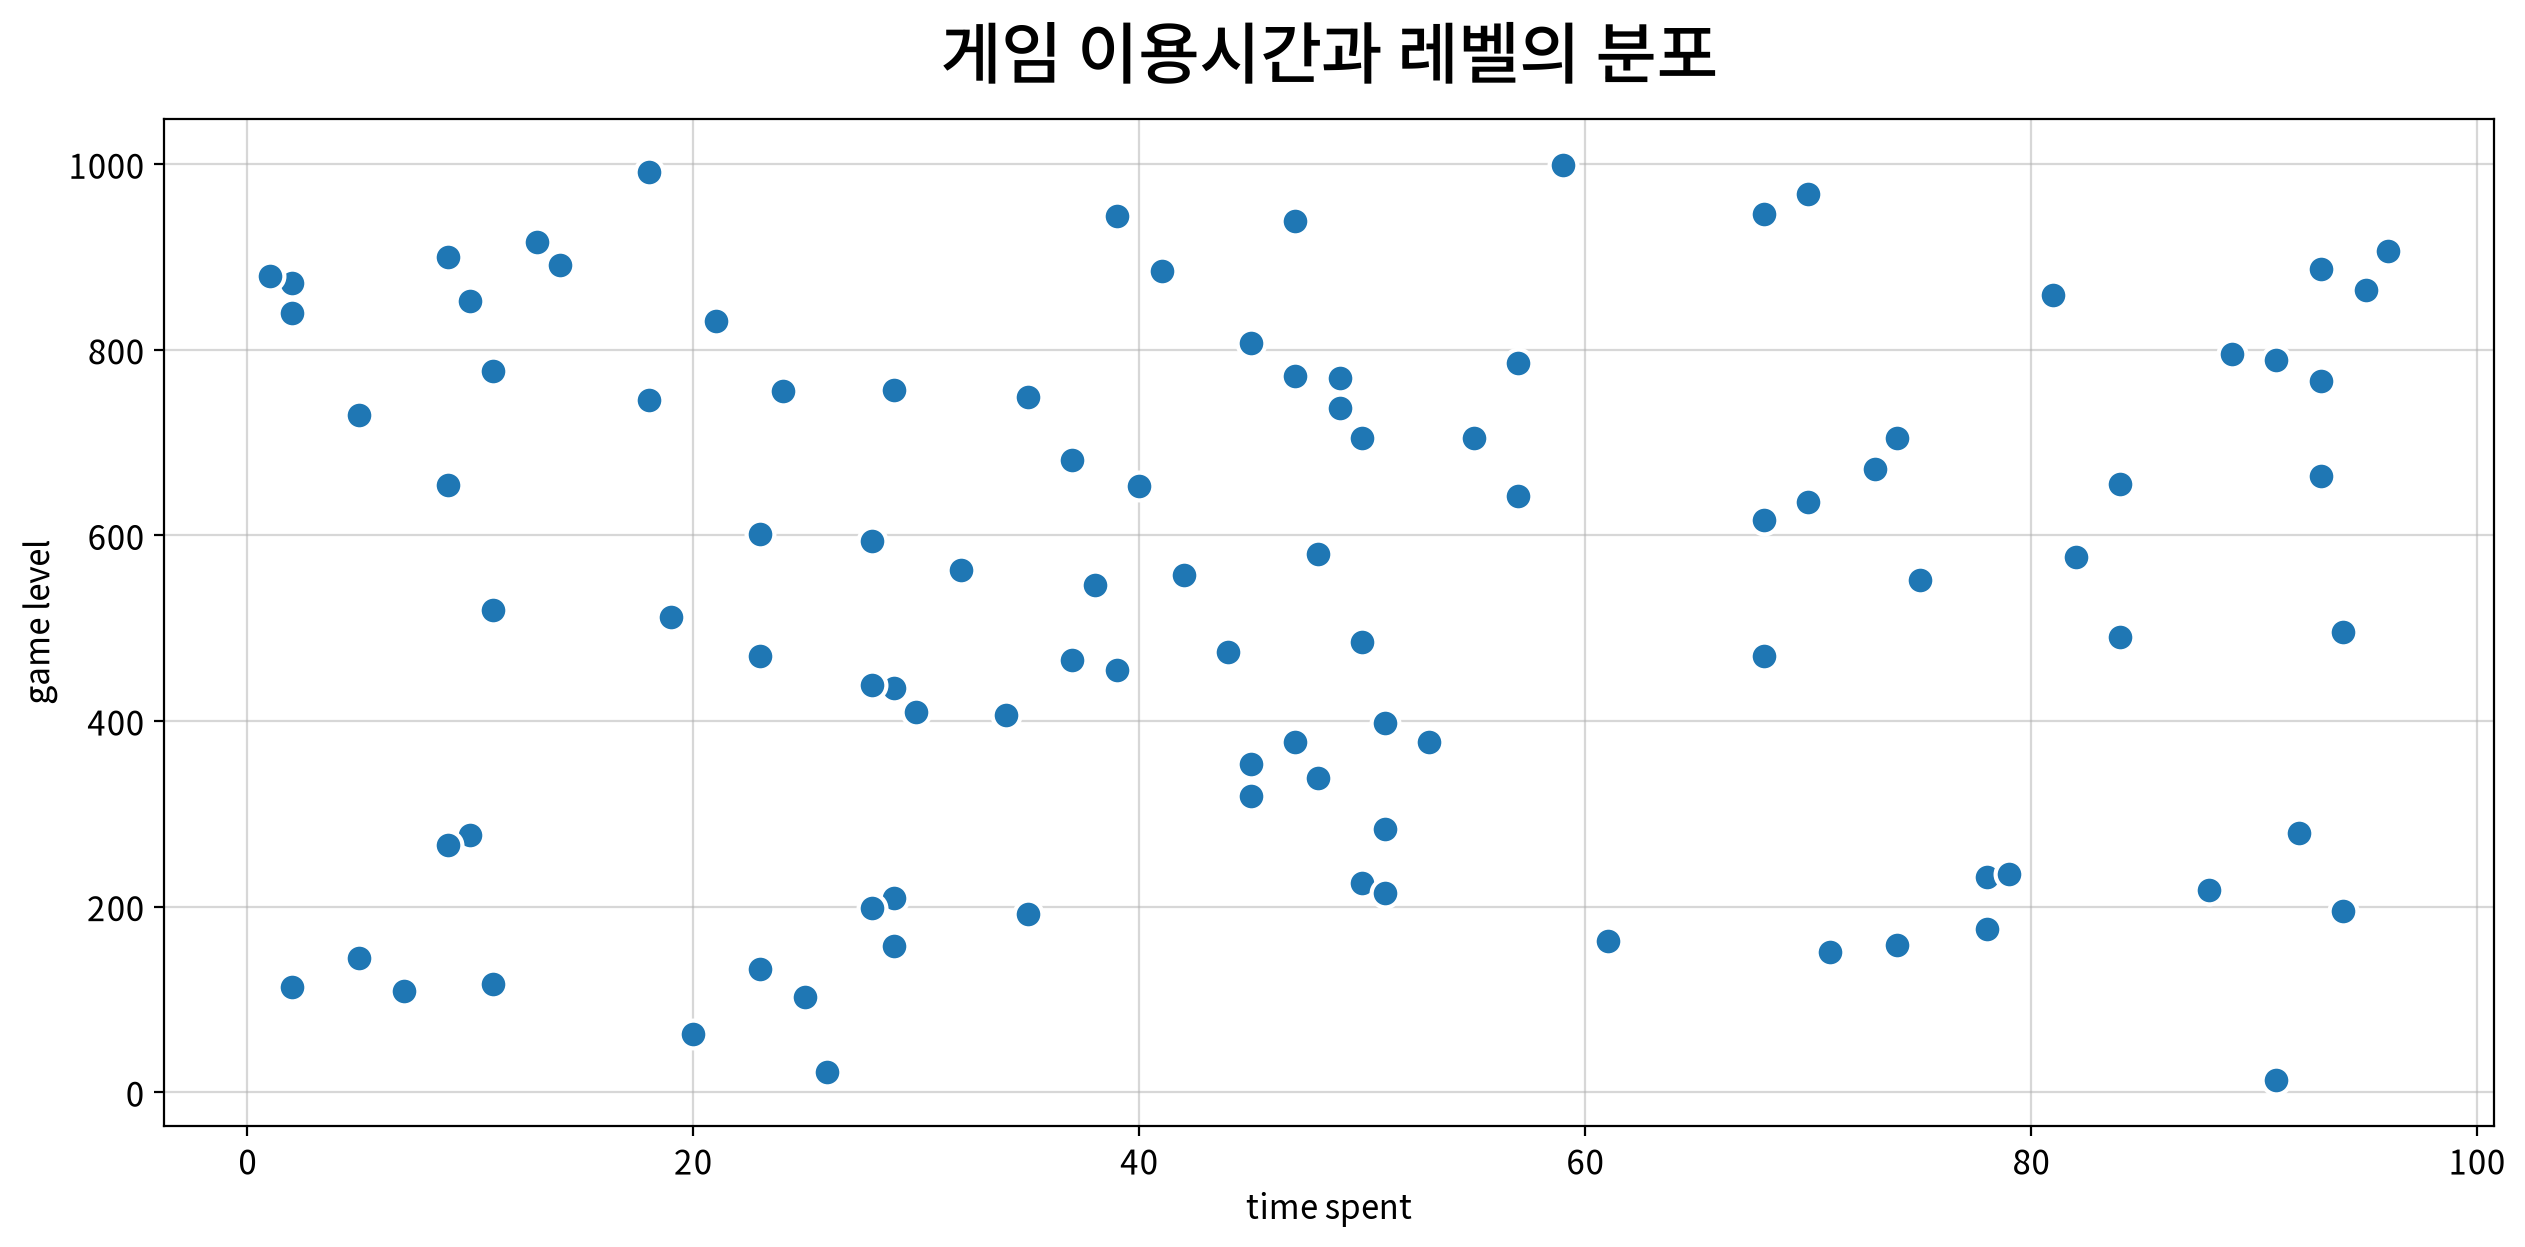

In [3]:
my_plot.scatterplot(data=origin, x="time spent", y="game level", 
                    title="게임 이용시간과 레벨의 분포")

## 사용할 데이터

게임 이용자 **100명**의 두 변수
- time spent (이용 시간)
- game level (레벨)

## 나누고 싶은 네 부류

- 오래 해서 잘하는
- 오래 했는데 못하는
- 잠깐 했는데 잘하는
- 잠깐 해서 못하는

---

**게임 이용시간과 레벨의 분포**

아직 그룹을 나누기 전, 100명이 흩어져 있는 모습

## #03. 군집화 Clustering 

### 1. 4개 그룹으로 군집화 시도 

In [4]:
# 모델 객체 생성 (그룹을 4개로 나눠 달라고 지시)
# RANDOM_STATE는 /helpers/__init__.py에 정의 되어있음 
estimator = KMeans(n_clusters=4, random_state=RANDOM_STATE)

# 모델 학습 (중심점을 찾는 과정)
estimator.fit(origin)

# 각 데이터가 몇번 그룹인지 확인 
cluster_pred = estimator.predict(origin)
cluster_pred

array([2, 1, 1, 2, 0, 1, 3, 3, 0, 3, 2, 1, 0, 3, 2, 0, 1, 0, 2, 3, 1, 2,
       0, 1, 0, 2, 1, 0, 3, 3, 1, 1, 3, 0, 1, 1, 3, 0, 0, 2, 0, 1, 2, 1,
       2, 1, 1, 3, 1, 0, 3, 0, 0, 0, 3, 2, 0, 1, 2, 3, 0, 1, 3, 3, 3, 1,
       3, 0, 3, 1, 2, 3, 0, 0, 2, 0, 2, 1, 0, 3, 0, 1, 3, 2, 0, 3, 1, 3,
       0, 0, 1, 1, 3, 1, 2, 2, 3, 2, 0, 3], dtype=int32)

### 2. 결과를 데이터 프레임으로 구성 

In [5]:
df = origin.copy()
df["그룹번호"] = cluster_pred
df.head()

,time spent,game level,그룹번호
0,39,944,2
1,55,705,1
2,29,757,1
3,59,999,2
4,7,109,0


### 3. 결과 시각화 

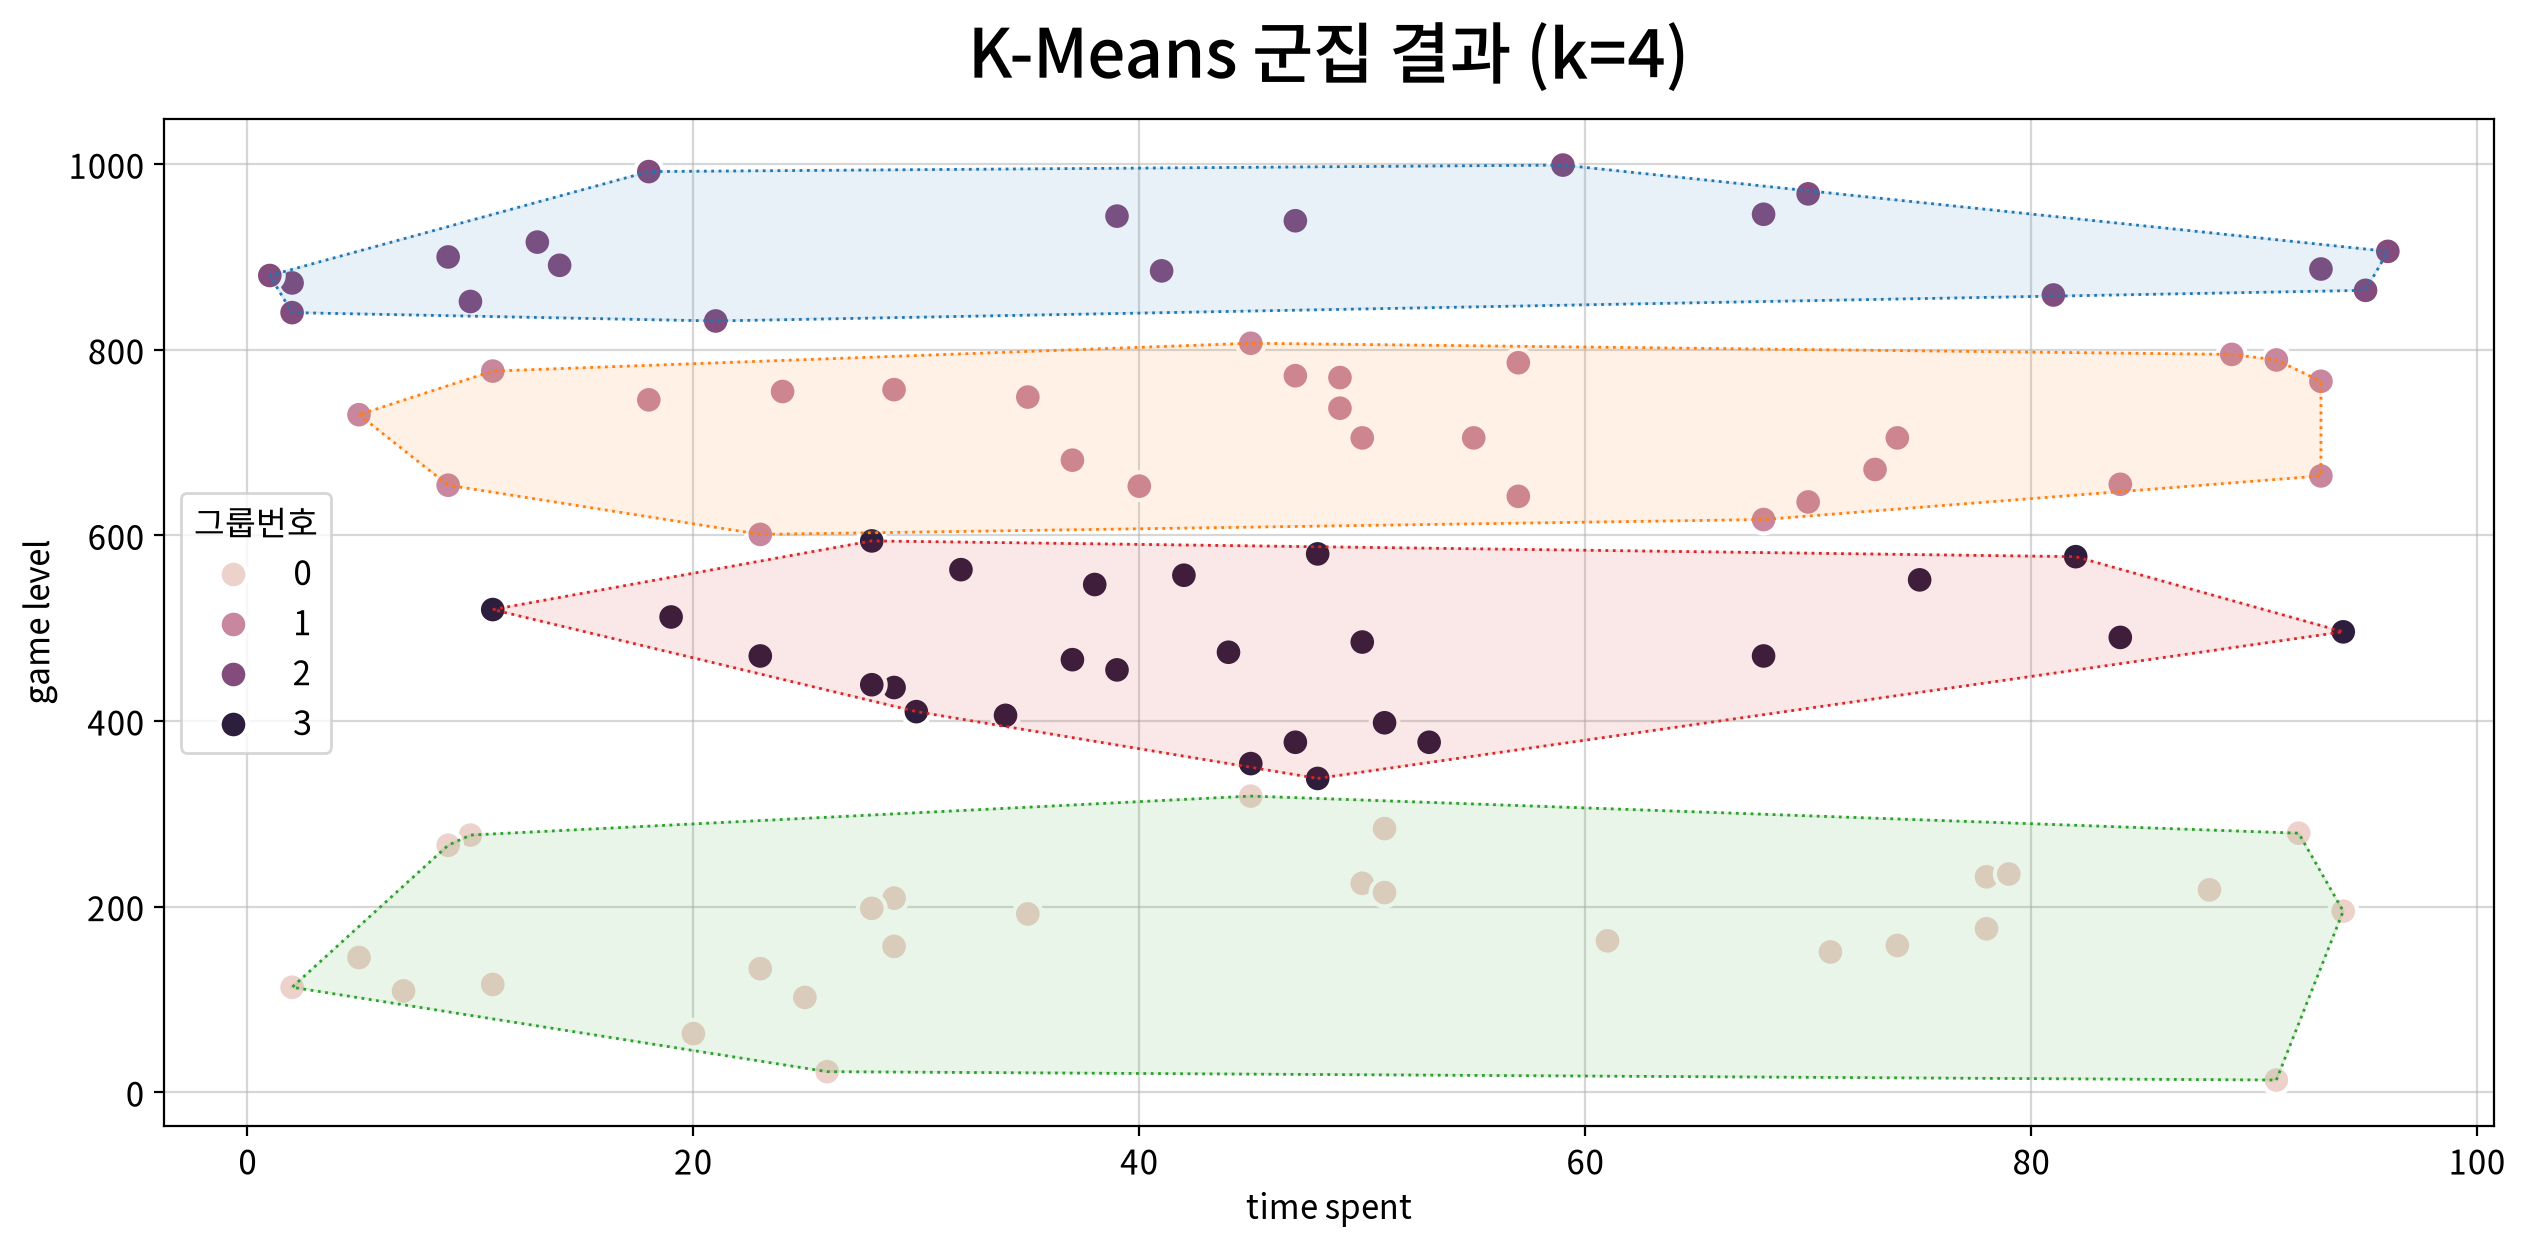

In [6]:
my_plot.scatterplot(data=df, x="time spent", y="game level", hue="그룹번호", 
                    outline=True, title="K-Means 군집 결과 (k=4)")

### 4. 모델이 찾은 중심점 
각 군집별 중심점의 좌표를 확인할 수 있다 \
    [x좌표, y좌표] 형태를 포함하는 2차원 리스트 -> DataFrame으로 변환 

In [7]:
center_df = DataFrame(estimator.cluster_centers_, 
                      columns=["x", "y"]) # 컬럼 이름 지정 
center_df

,x,y
0,45.071,177.321
1,50.926,715.741
2,41.000,903.737
3,45.346,474.731


## 5. 군집 결과 시각화 + 중심점 표시

◎ 시각화 결과물에 여기에 모델이 찾아낸 **중심점(cluster_centers_)** 을 \
**빨간 X**로 덧그리면 K-Means가 무엇을 했는지 한눈에 보인다.

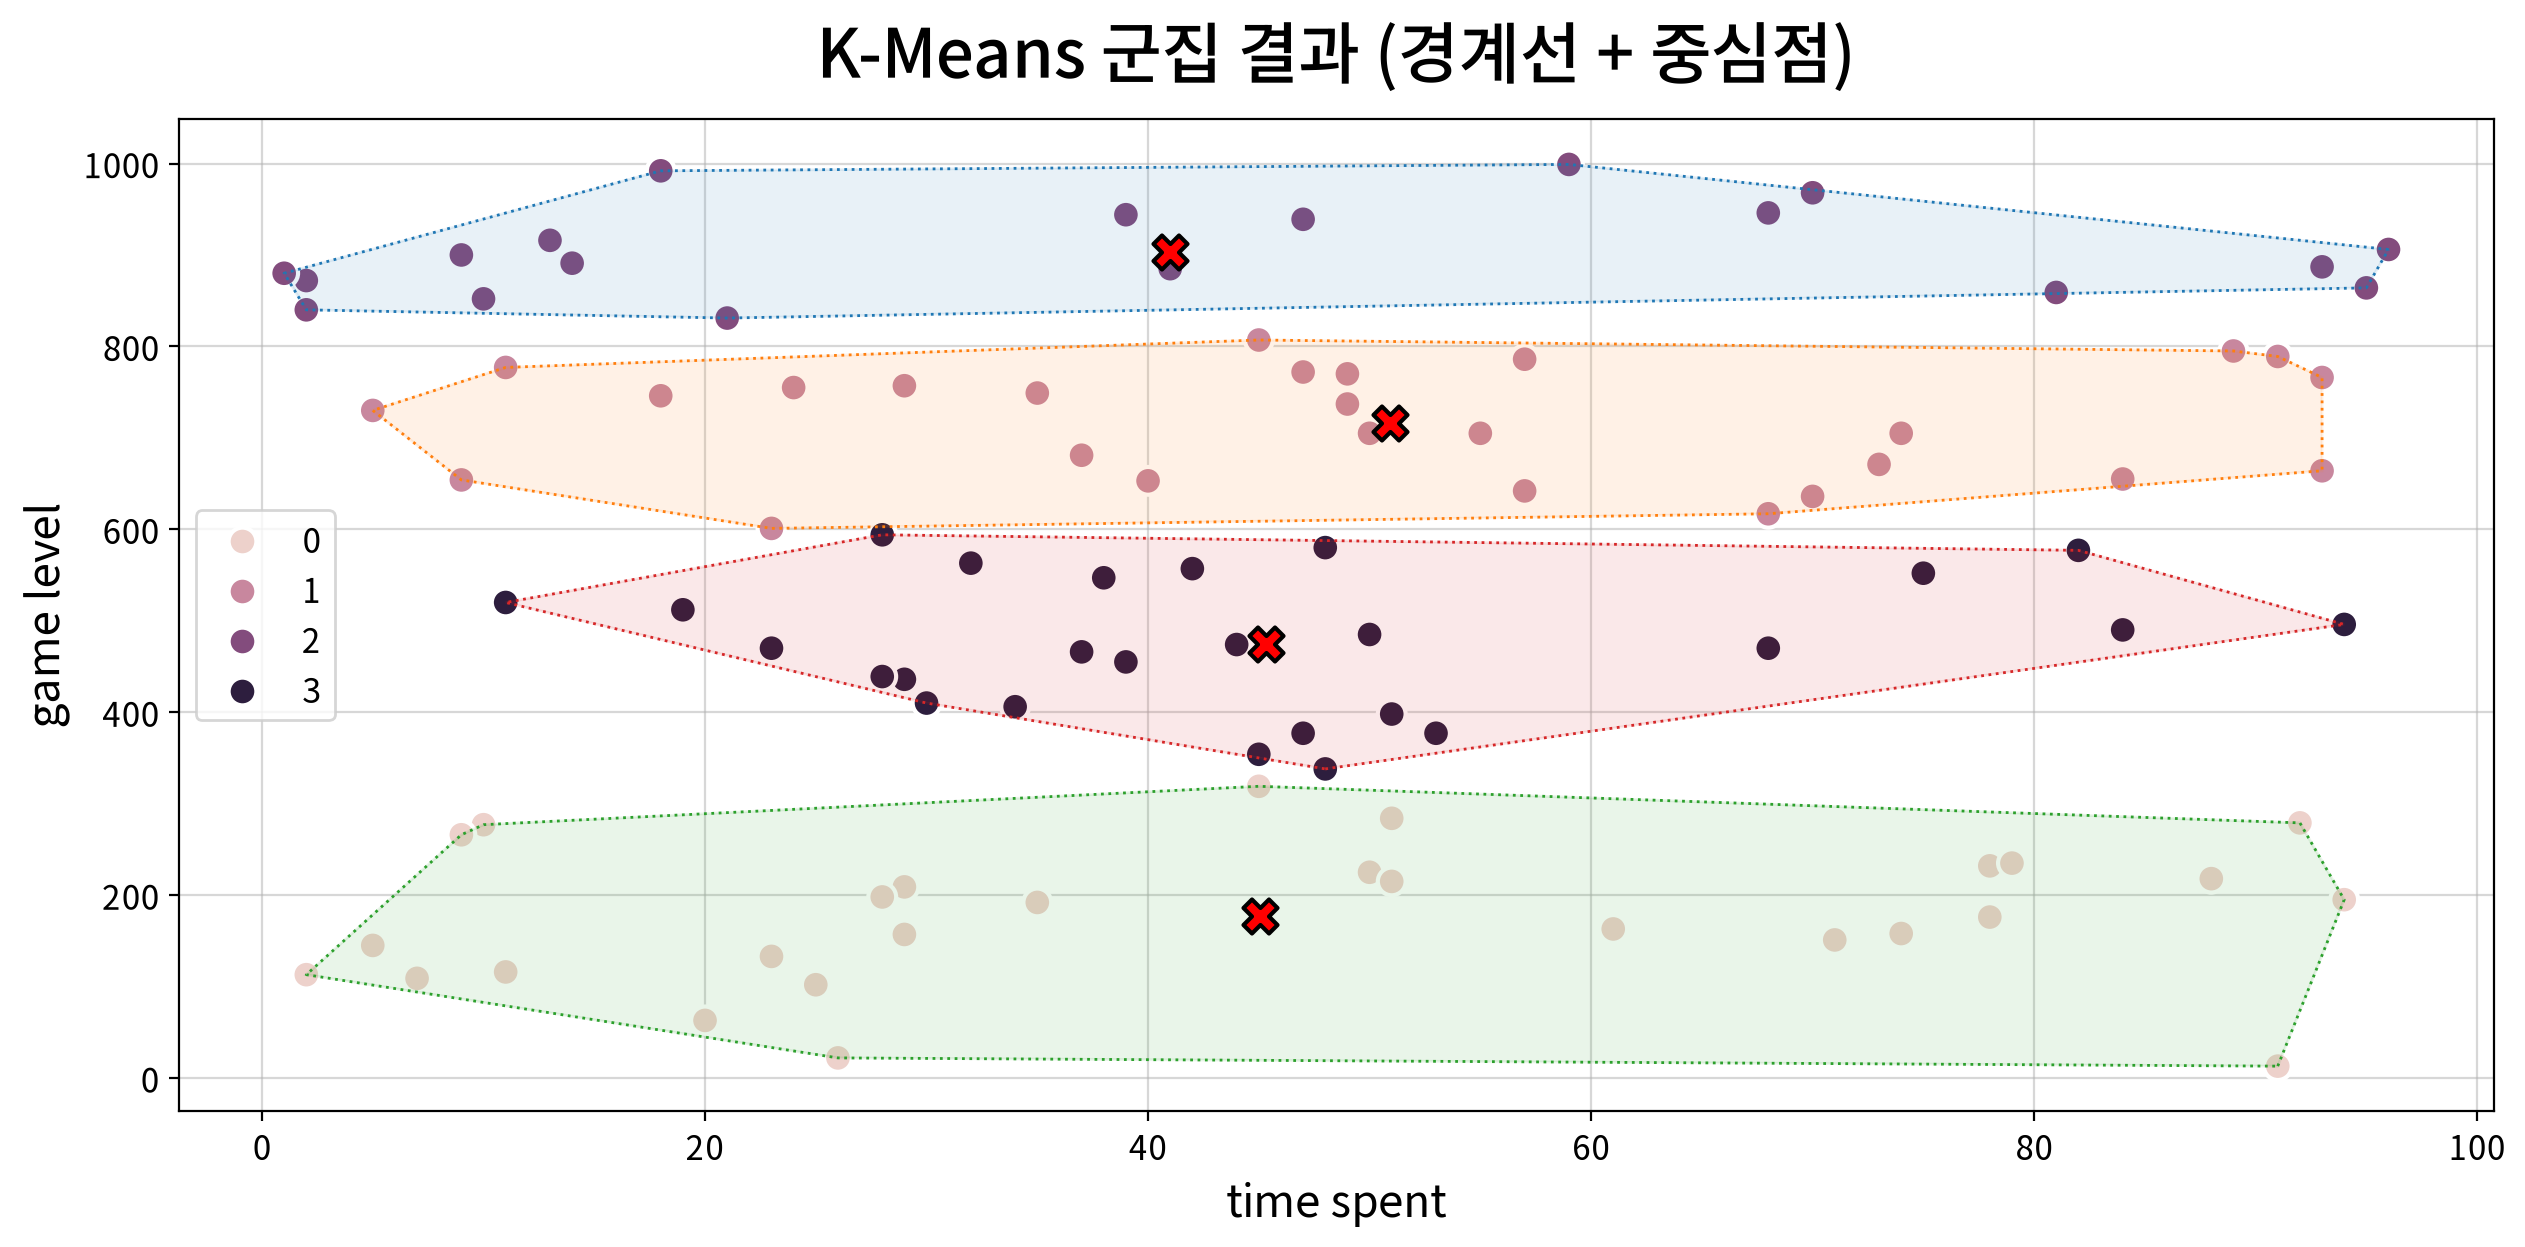

In [8]:
x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="K-Means 군집 결과 (경계선 + 중심점)",
                        xlabel=x_field, ylabel=y_field)

# 군집별 산점도 시각화 (경계선 표시)
my_plot.scatterplot(data=df, x=x_field, y=y_field, hue="그룹번호",
                     outline=True, ax=ax)

# 모델이 찾은 중심점 표시 (중심점의 x좌표에 대한 y좌표 산점도)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X",
                     size=150, color="#ff0000", edgecolor="#000000", ax=ax)

my_plot.show()

### 5. 군집 결과 시각화 + 중심점 표시 (결과확인)

**K-Means 군집 결과 (경계선 + 중심점)**

**점 색깔**
0 · 1 · 2 · 3 그룹 번호

**점선 테두리**
각 그룹의 경계선

**빨간 X**
각 그룹의 중심점

> 그룹이 **위아래로만 층층이 잘려 있다.** 가로 방향은 전혀 반영되지 않았다. 왜 그럴까?

## #04. 데이터 표준화 적용 

### 1. 두 축의 범위를 똑같이 맞춰서 다시 확인

◎ time spent 와 game level 은 값의 범위가 서로 다르다.
- x축의 범위를 y축과 똑같이 맞춰서 그려 보면, \
    실제로 K-Means가 본 그림이 어떤 모양이었는지 알 수 있다.

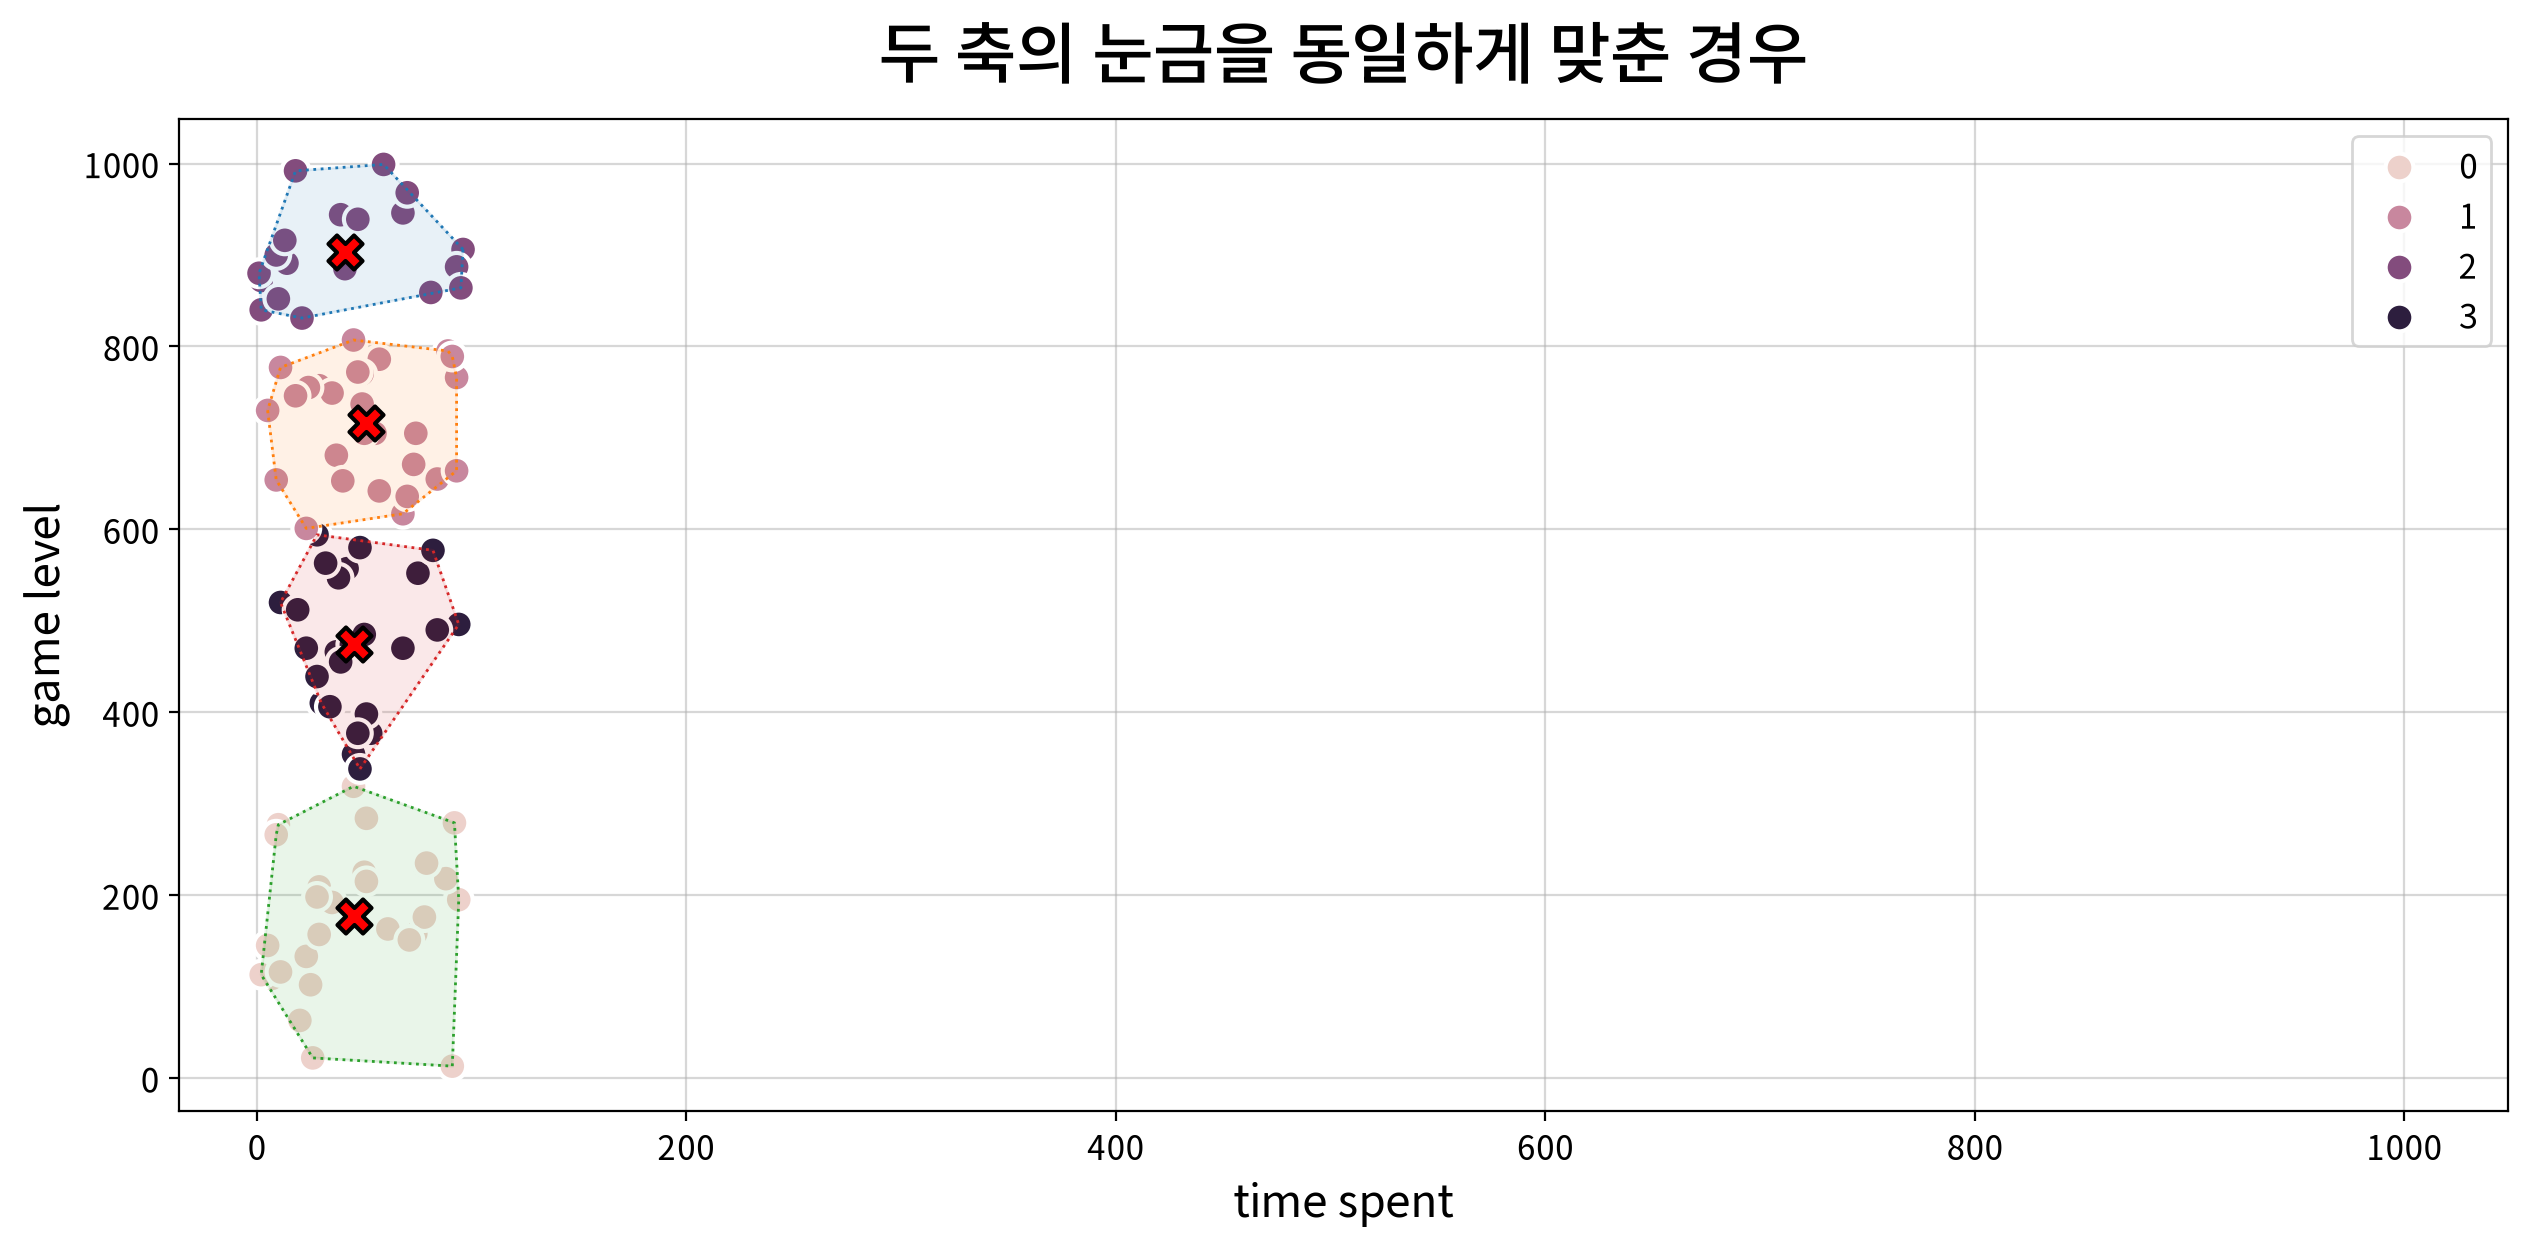

In [9]:
x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="두 축의 눈금을 동일하게 맞춘 경우",
                        xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=df, x=x_field, y=y_field, hue="그룹번호",
                     outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X",
                     size=150, color="#ff0000", edgecolor="#000000", ax=ax)

# x축의 범위를 y축과 동일하게 설정
ax.set_xlim(ax.get_ylim())

my_plot.show()

## #04. 데이터 표준화 적용

### 1. 두 축의 범위를 똑같이 맞춰서 다시 확인 (결과 확인)

> 값의 범위가 큰 변수 하나가 거리 계산을 독차지했기 때문이다.

**두 축의 눈금을 동일하게 맞춘 경우**

#### 두 변수의 값 범위

| 변수 | 값의 범위 | 표준편차 |
|---|---|---|
| time spent | 1 ~ 96 | 27.9 |
| game level | 13 ~ 999 | 276.7 |

그래서 그룹이 game level 값에 따라 가로 띠 모양으로 층층이 나뉘었다.

---

결과 그림에서 그룹이 **위아래로만 층층이 잘려 있다**\
↓\
두 축 눈금을 맞춰 보면 데이터가 **세로로 길쭉하게** 늘어서 있다\
↓\
game level 쪽의 값 차이가 time spent 보다 약 10배 크다\
↓
> 거리를 잴 때 사실상 **game level** 하나만 보고 그룹을 나눈 셈

### 2. 데이터 표준화 (StandardScaler) 적용

◎ 데이터의 **평균을 0, 표준편차를 1로 맞춘다**.
- 즉, **데이터간의 거리를 동일한 범위로 통일**한다.

In [10]:
sdf = my_prep.scaling(origin, method="standard")
sdf.head()

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00            -1.62~1.81
game level        13.00 ~ 999.00            -1.91~1.67


,time spent,game level
0,-0.251,1.475
1,0.326,0.607
2,-0.612,0.795
3,0.471,1.675
4,-1.405,-1.559


### 3. 스케일링 된 데이터로 다시 군집화 

In [11]:
# 모델 객체 생성 
estimator = KMeans(n_clusters=4, random_state=RANDOM_STATE)

# 모델 학습 
estimator.fit(sdf)

# 군집 결과를 컬럼으로 추가 
sdf["그룹번호"] = estimator.predict(sdf)    
sdf.head()

,time spent,game level,그룹번호
0,-0.251,1.475,1
1,0.326,0.607,2
2,-0.612,0.795,1
3,0.471,1.675,2
4,-1.405,-1.559,3


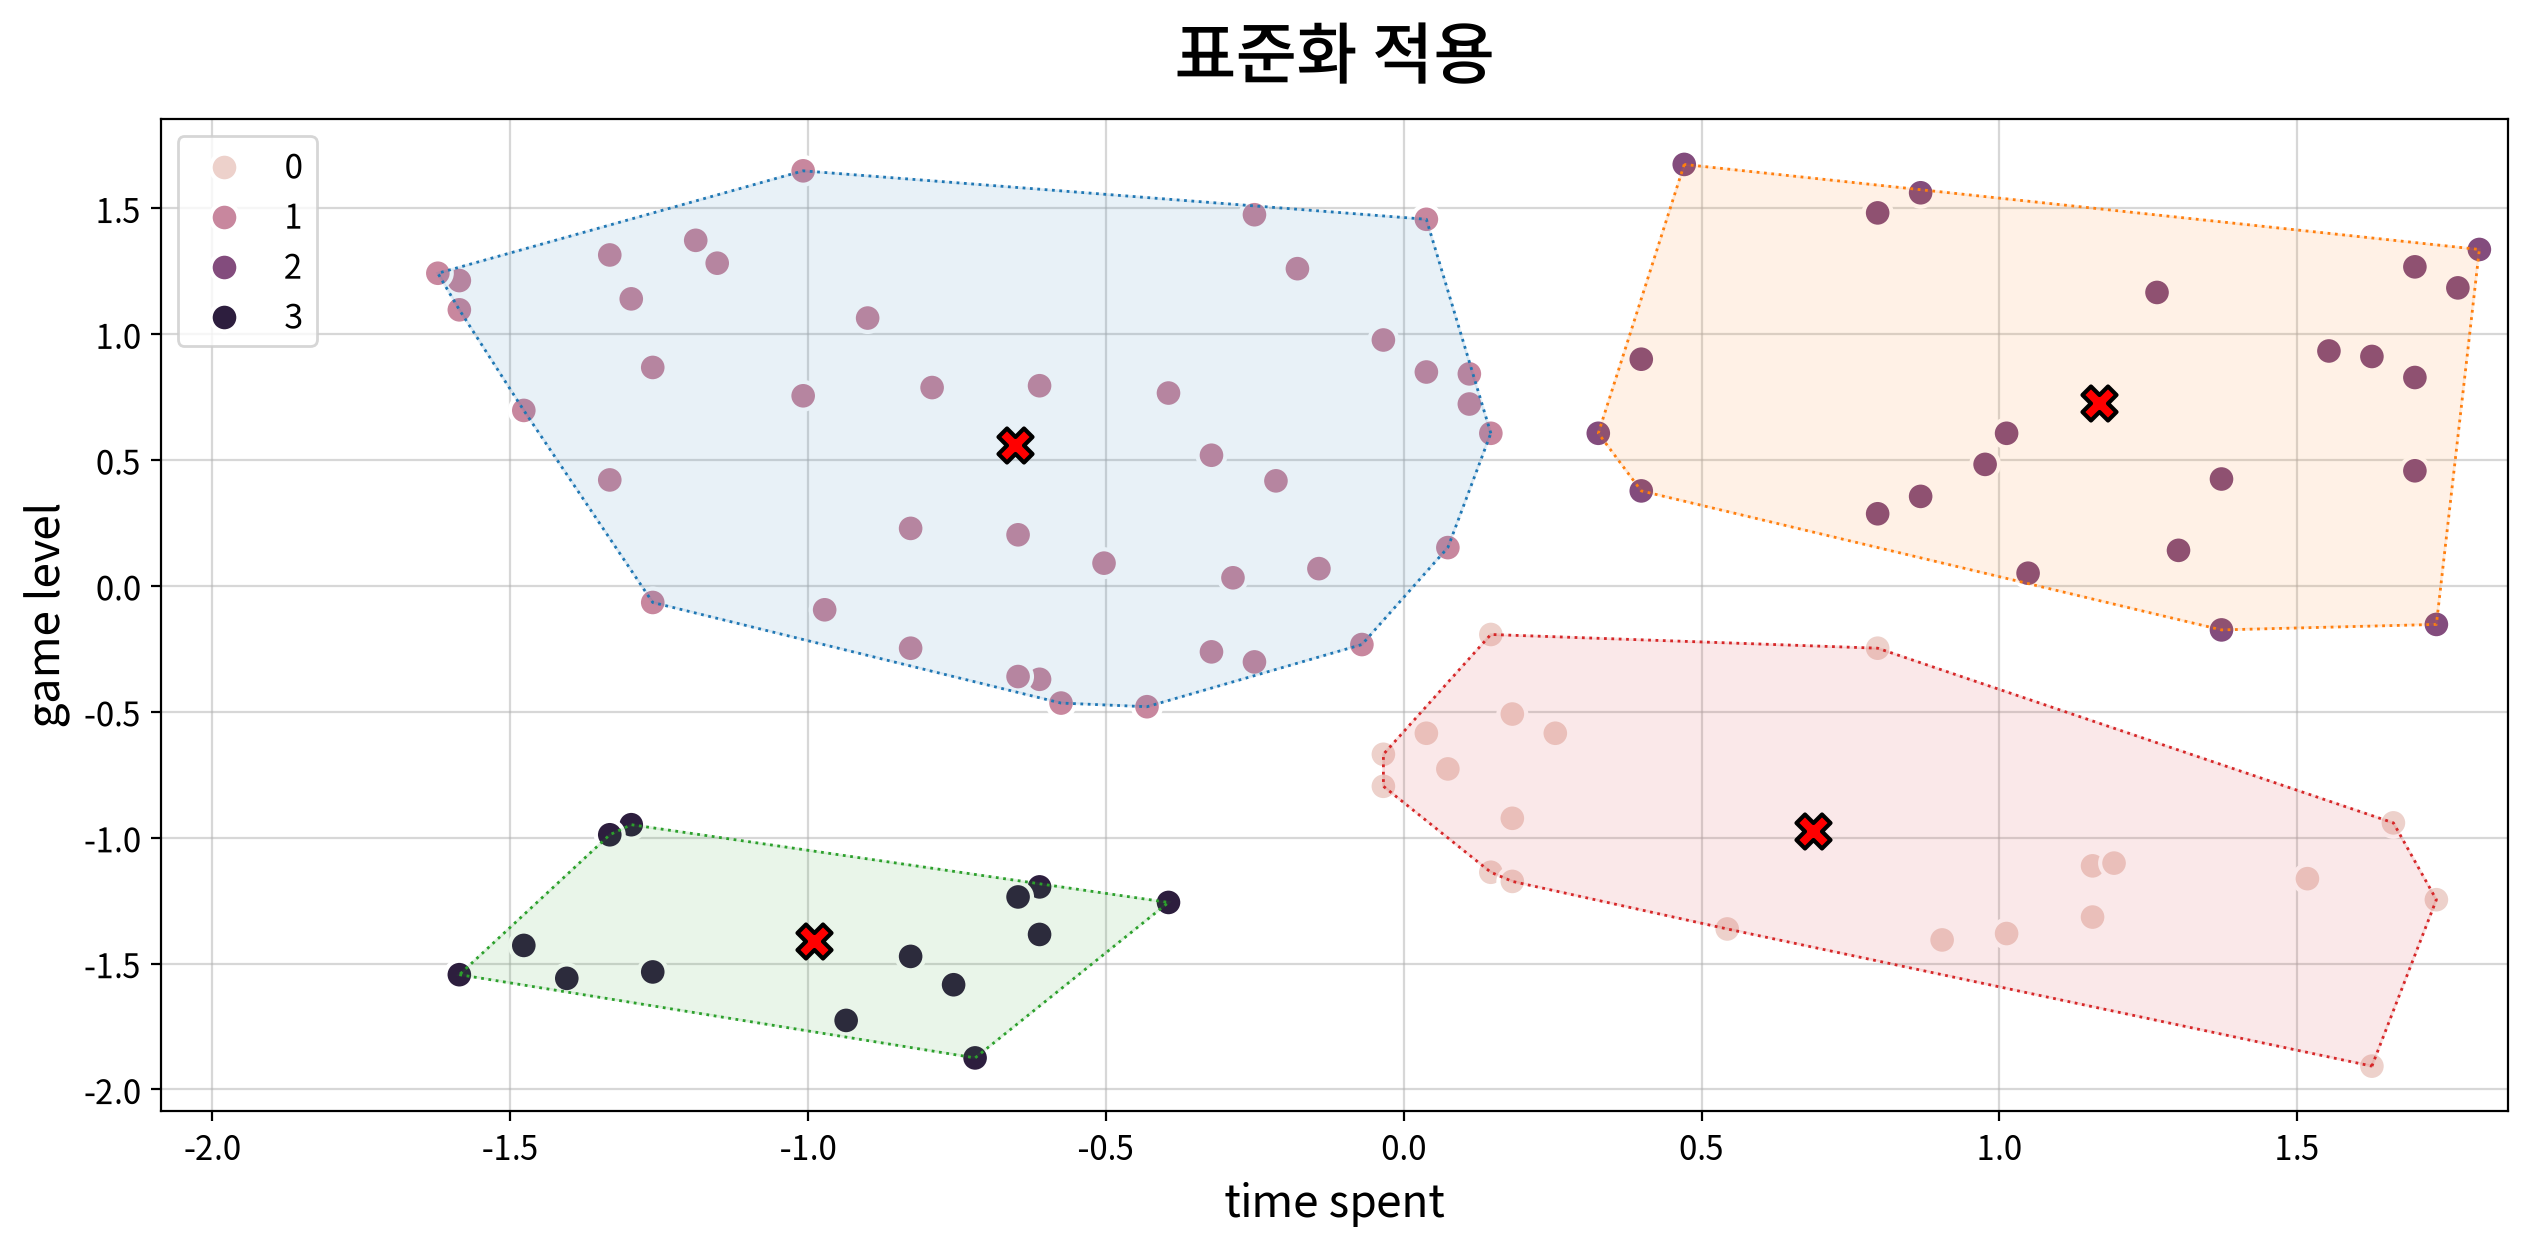

In [12]:
# 중심점
center_df = DataFrame(estimator.cluster_centers_, columns=["x", "y"])

x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="표준화 적용",
                        xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=sdf, x=x_field, y=y_field, hue="그룹번호",
                     outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X",
                     size=150, color="#ff0000", edgecolor="#000000", ax=ax)

ax.set_xlim(ax.get_ylim())

my_plot.show()

## #05. 데이터 정규화 적용 

### 1. 데이터 정규화 (MinMaxScaler)를 적용하여 군집화 수행 \
데이터의 범위를 0~1 사이로 맞춘다 
    

In [13]:
mdf = my_prep.scaling(origin, method="minmax")

estimator = MiniBatchKMeans(n_clusters=4, random_state=RANDOM_STATE)
estimator.fit(mdf)
mdf["그룹번호"] = estimator.predict(mdf)
mdf.head()

MinMaxScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00             0.00~1.00
game level        13.00 ~ 999.00             0.00~1.00


,time spent,game level,그룹번호
0,0.400,0.944,3
1,0.568,0.702,1
2,0.295,0.755,3
3,0.611,1.000,3
4,0.063,0.097,2


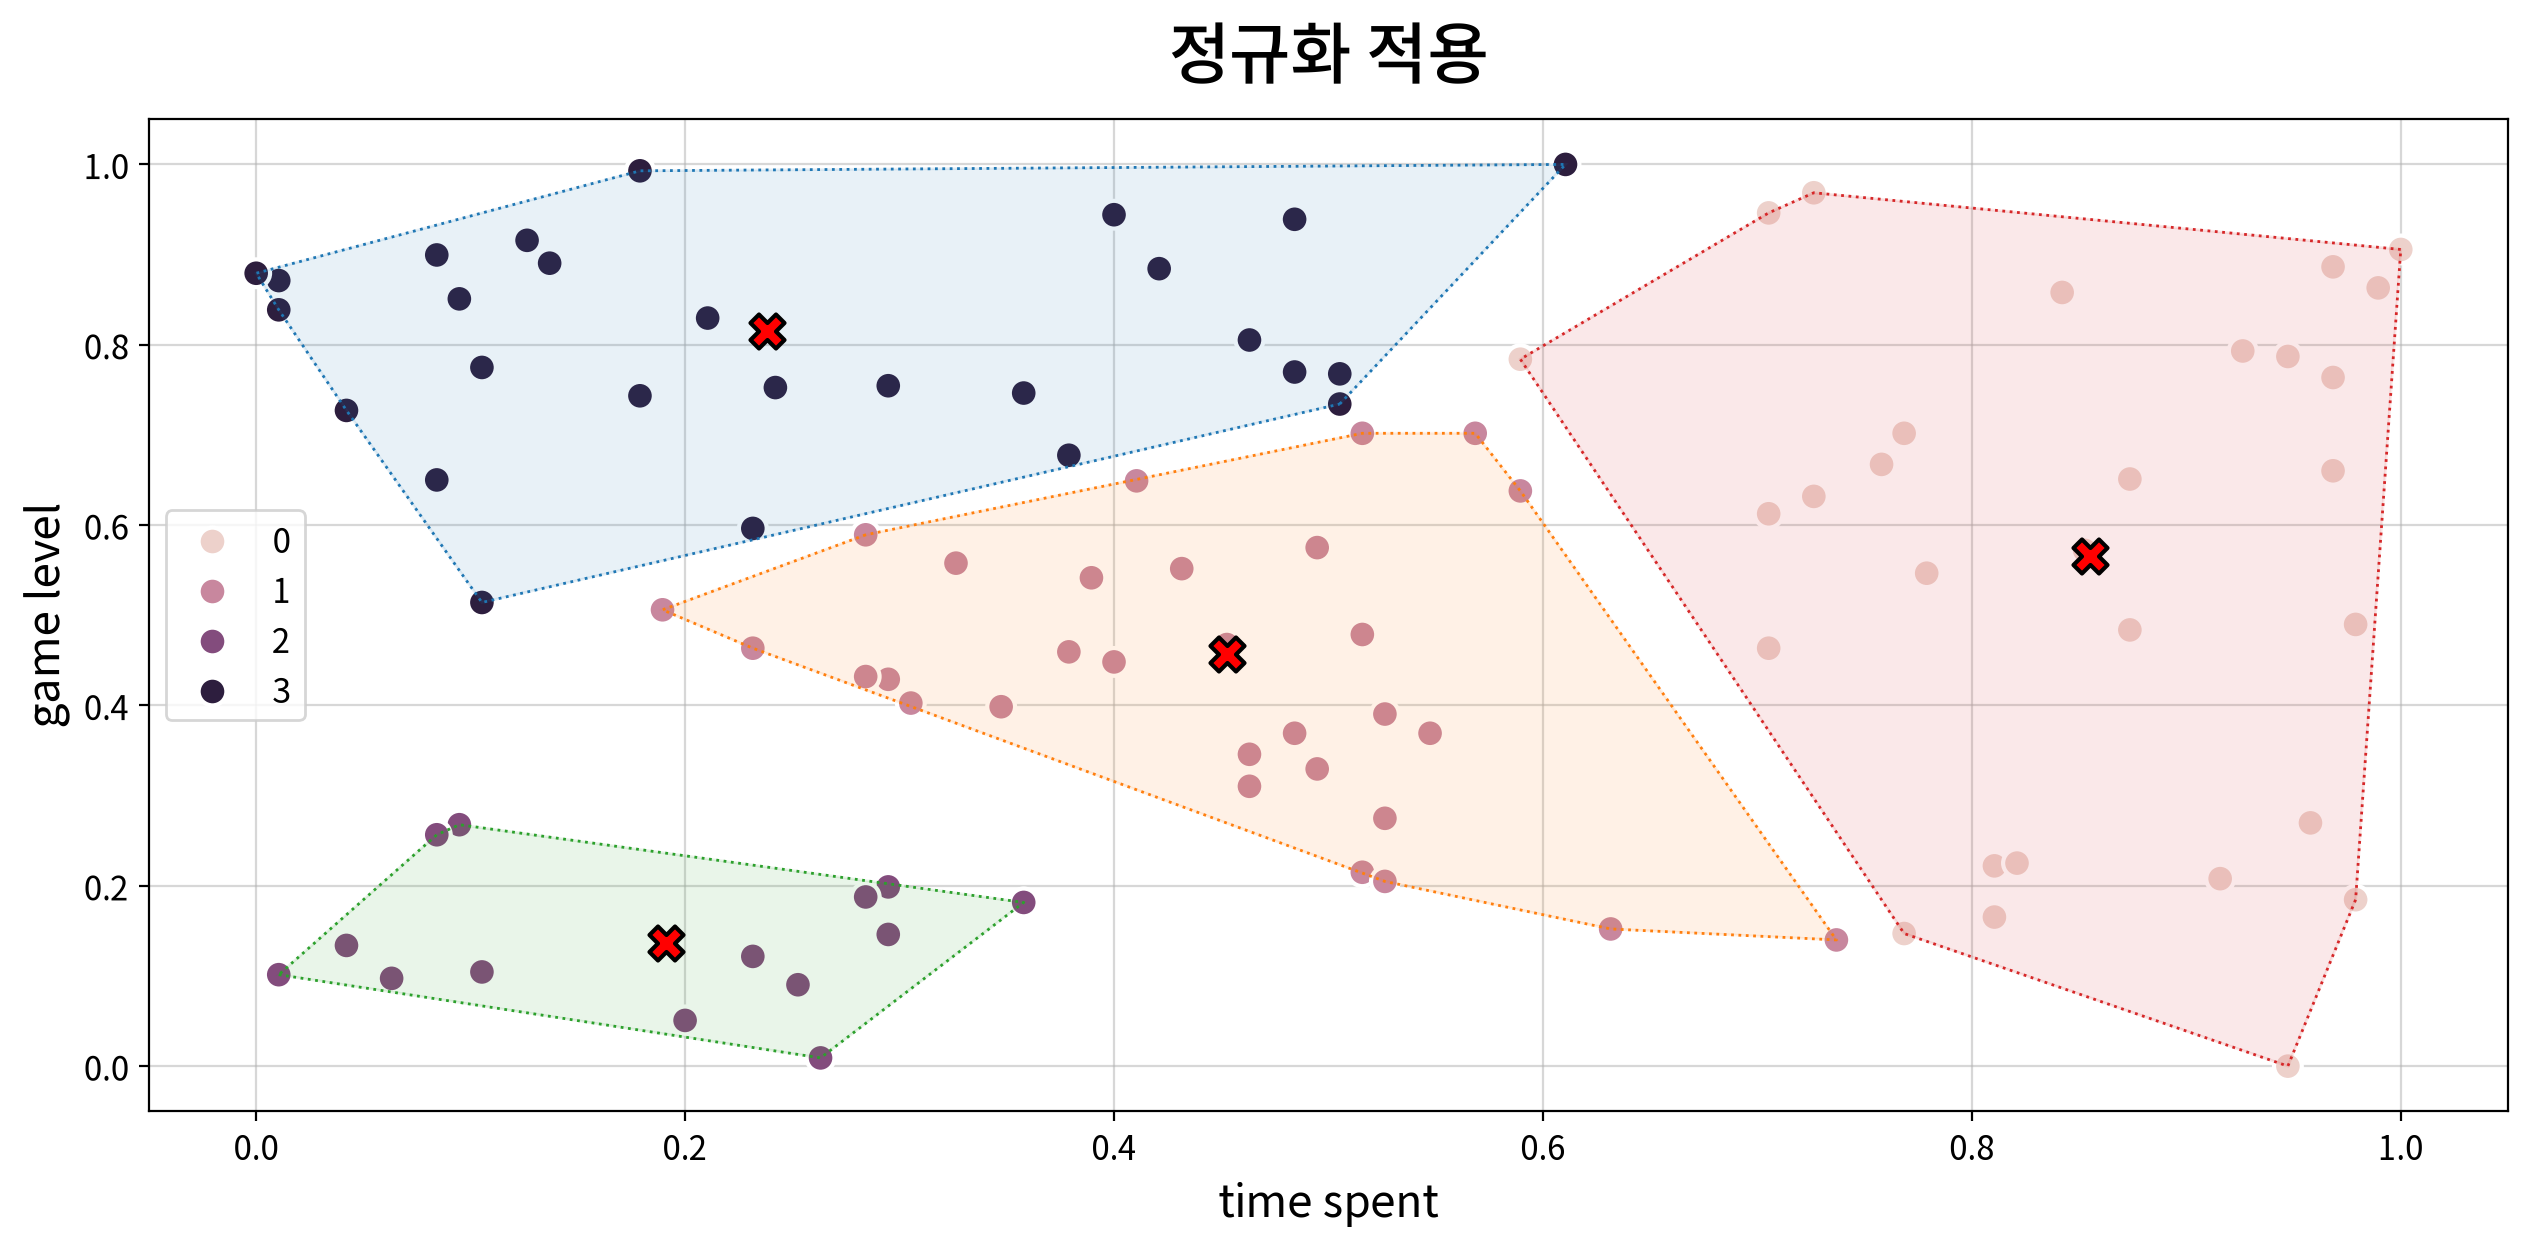

In [14]:
# 중심점
center_df = DataFrame(estimator.cluster_centers_, columns=["x", "y"])

x_field = "time spent"
y_field = "game level"

fig, ax = my_plot.init(title="정규화 적용",
                        xlabel=x_field, ylabel=y_field)

my_plot.scatterplot(data=mdf, x=x_field, y=y_field, hue="그룹번호",
                     outline=True, ax=ax)
my_plot.scatterplot(data=center_df, x="x", y="y", marker="X",
                     size=150, color="#ff0000", edgecolor="#000000", ax=ax)

ax.set_xlim(ax.get_ylim())

my_plot.show()

## 어떤 스케일링을 사용하는 것이 좋을까?

### □ 표준화(StandardScaler)와 정규화(MinMaxScaler) 비교

> 기본은 표준화, 정규화 반드시 데이터의 범위가 0~1로 제한되어야 하는 경우에만 사용한다.

| 구분 | MinMaxScaler (정규화) | StandardScaler (표준화) |
|---|---|---|
| 변환 방식 | 0~1 범위로 맞춤 | 평균 0, 표준편차 1 |
| 수식 | (x - 최소) ÷ (최대 - 최소) | (x - 평균) ÷ 표준편차 |
| **이상치 영향** | **매우 큼 (최댓값 하나에 좌우)** | **상대적으로 작음** |
| K-Means 적합성 | 조건부 | **기본 선택** |

## #06. 모듈화 기능 확인 
### 1. 기본값으로 호출 (표준화 + 외곽선 + 중심점)

StandardScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00            -1.62~1.81
game level        13.00 ~ 999.00            -1.91~1.67


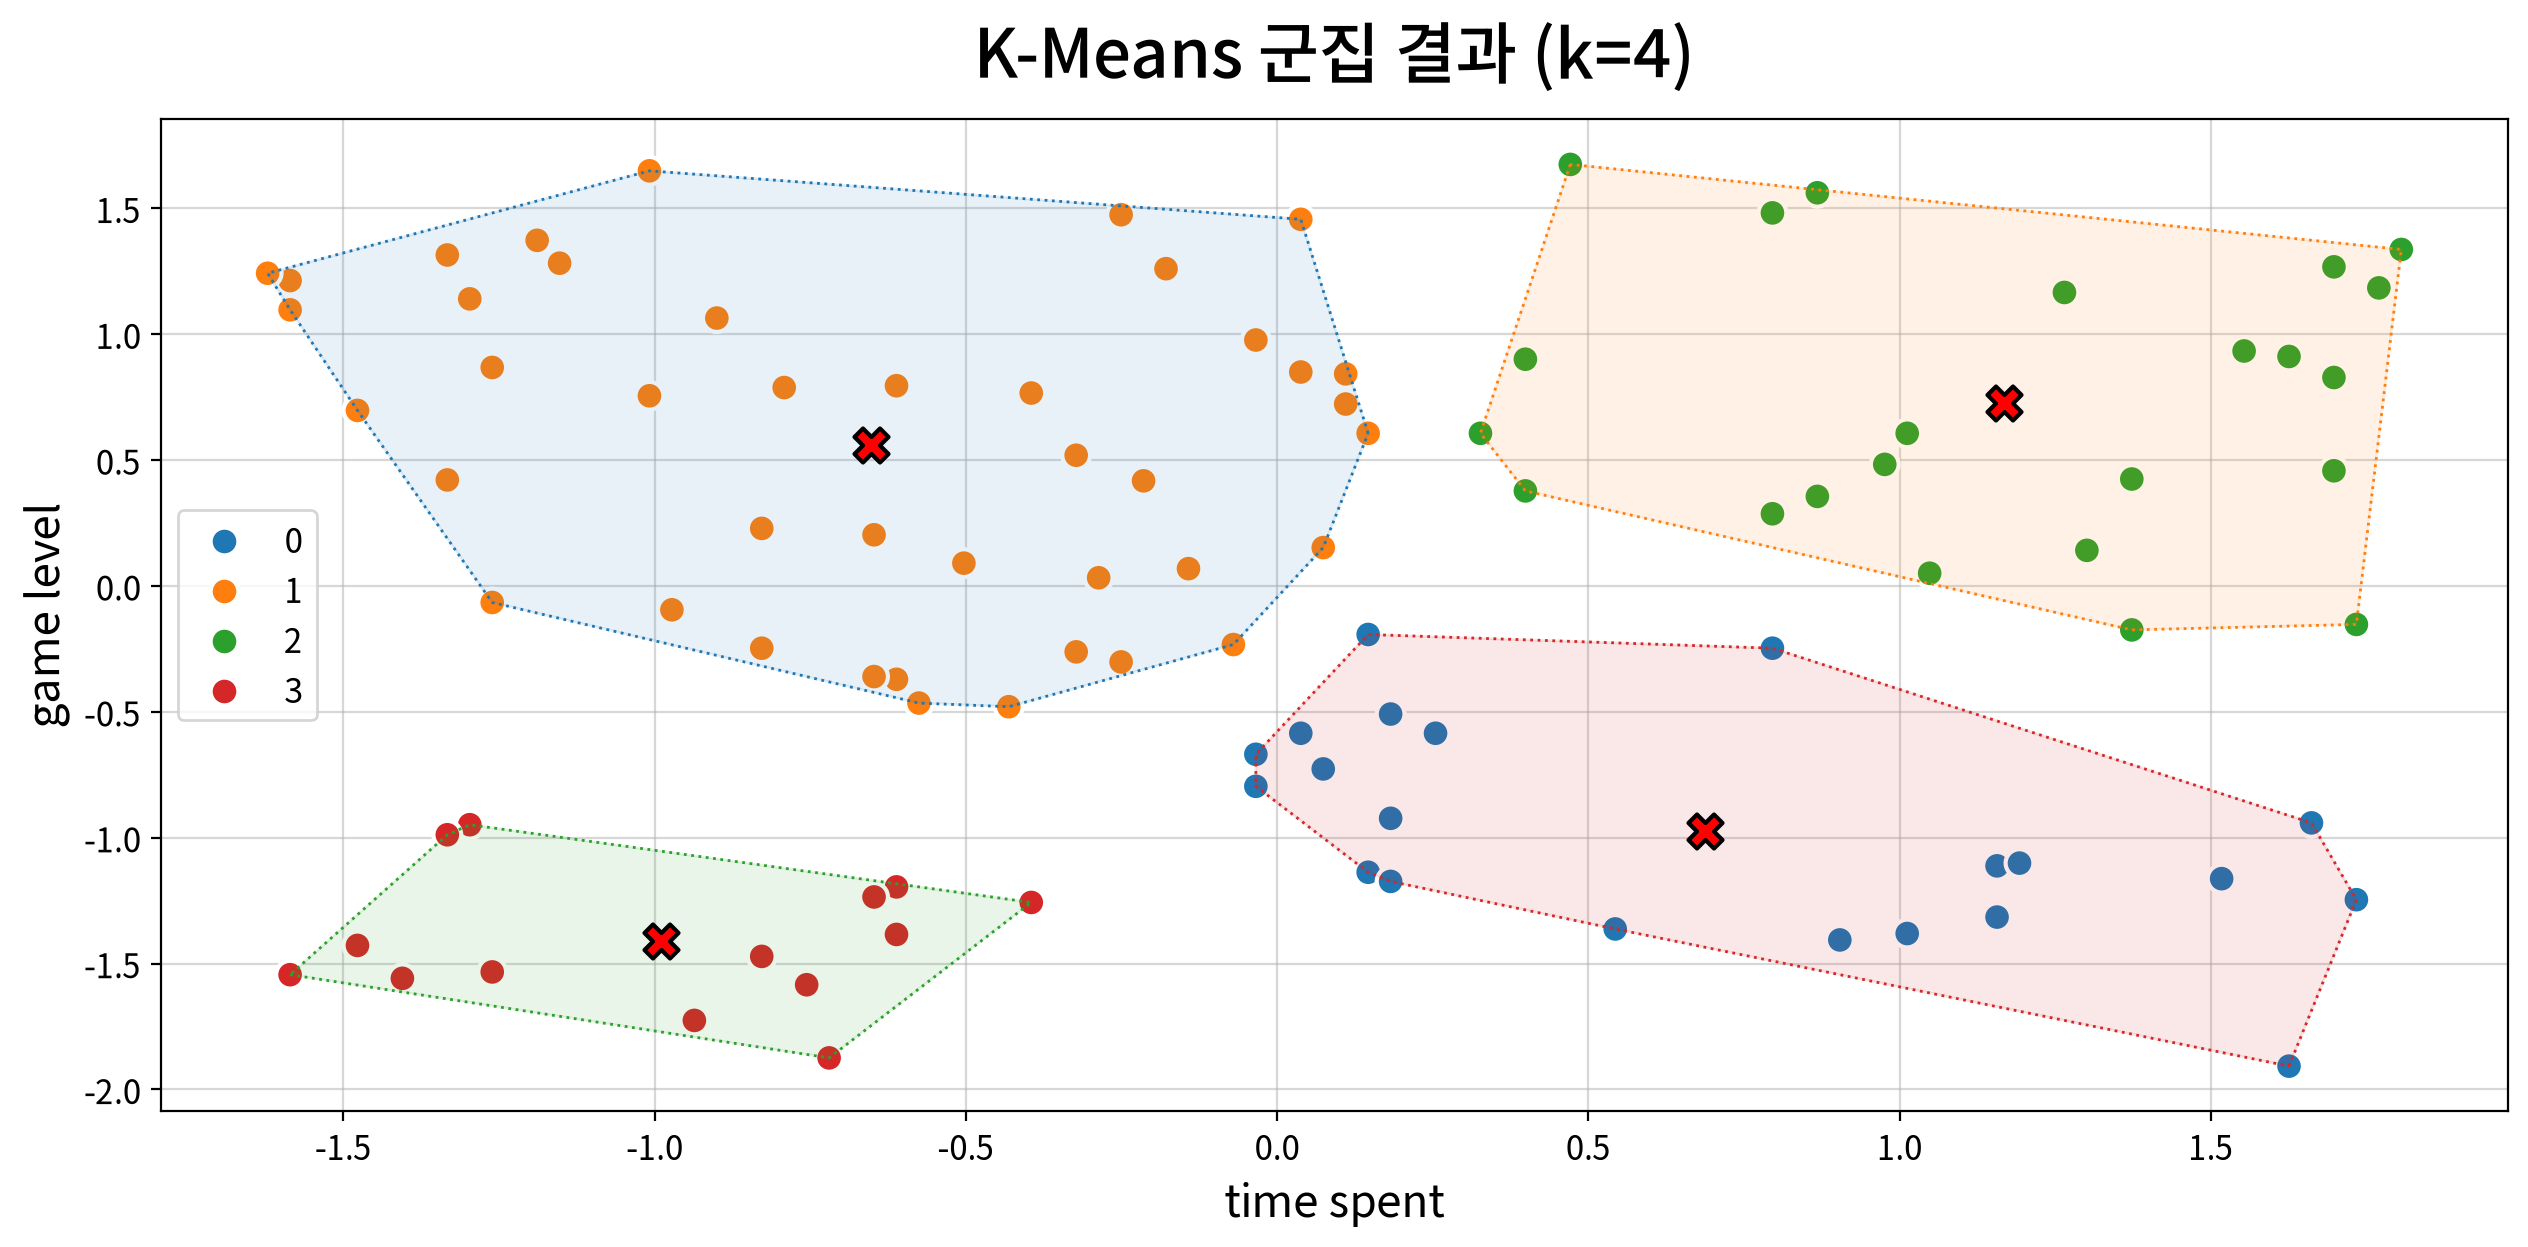

,time spent,game level,그룹번호
0,-0.251,1.475,1
1,0.326,0.607,2
2,-0.612,0.795,1
3,0.471,1.675,2
4,-1.405,-1.559,3


In [15]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4)
df.head()

### 2. 스케일링 미적용 + 두 축의 눈금을 동일하게 맞추기 

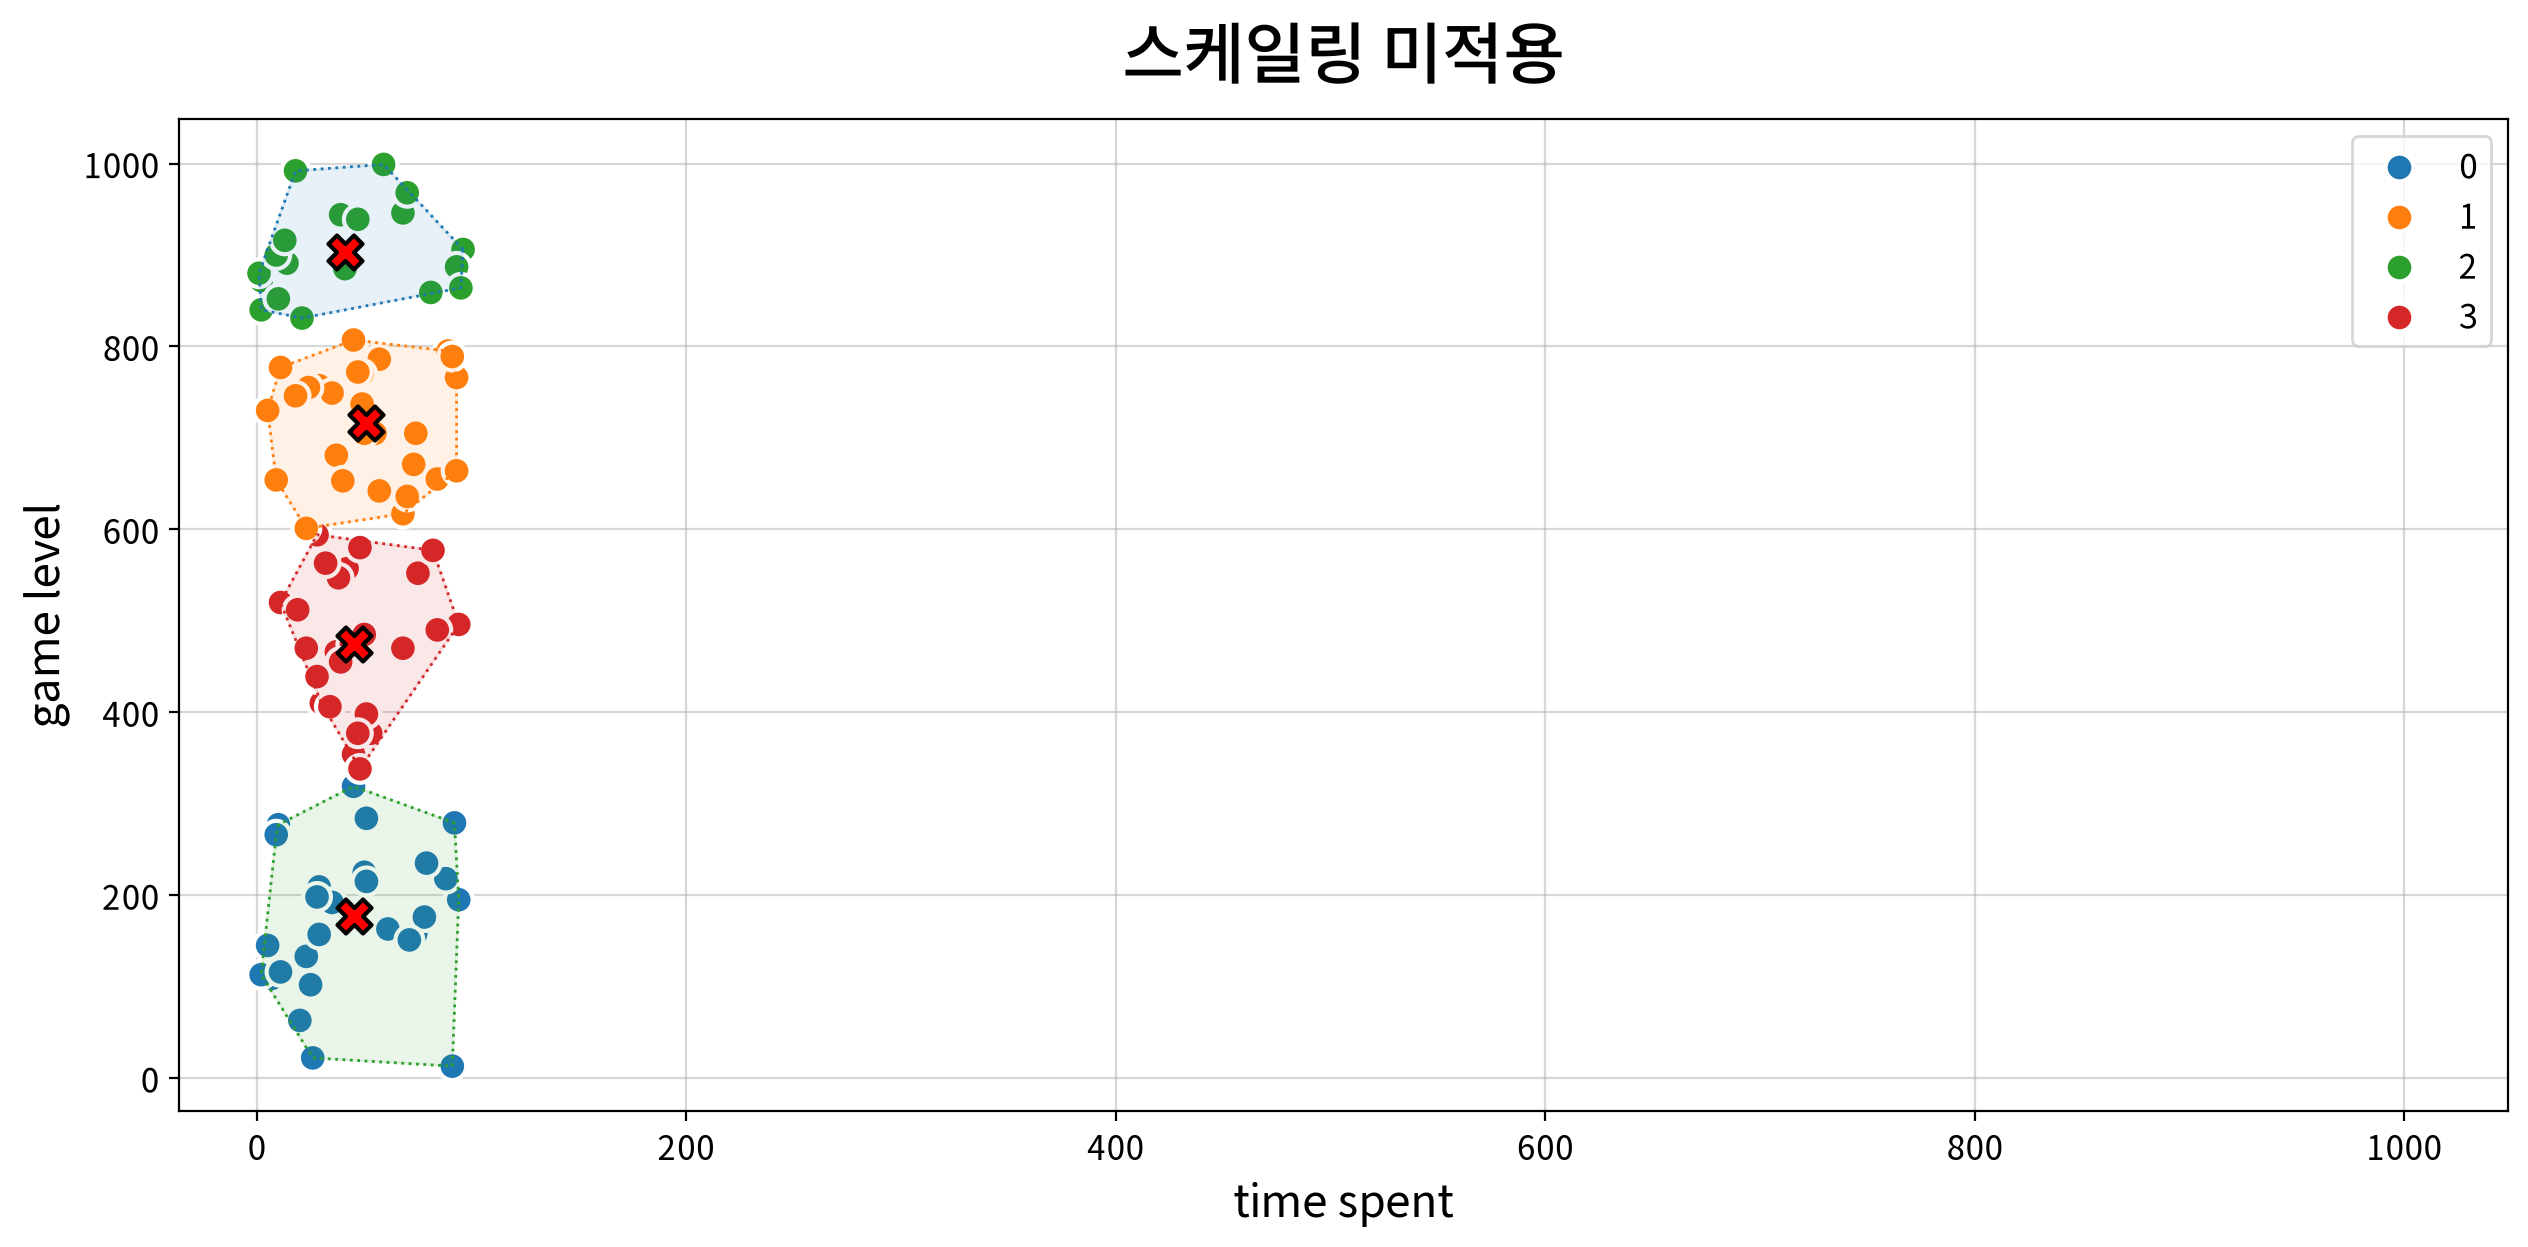

In [16]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4, scaling=None, 
                                             equal_scale=True, title="스케일링 미적용")

그래프는 함수 내부에서 자동으로 출력하지만, \
그 밖의 정보는 리턴값으로 받는다.\
위 코드는 리턴 받은 객체를 따로 출력하고 있지는 않기 때문에\
이 블록은 시각화 결과만 출력된다.

### 3. 정규화 적용 + 중심점 모양, 크기, 색상 변경 + 외곽선 미표시 

MinMaxScaler 적용 (2개 컬럼)
컬럼                            변환 전                  변환 후
--------------------------------------------------------
time spent          1.00 ~ 96.00             0.00~1.00
game level        13.00 ~ 999.00             0.00~1.00


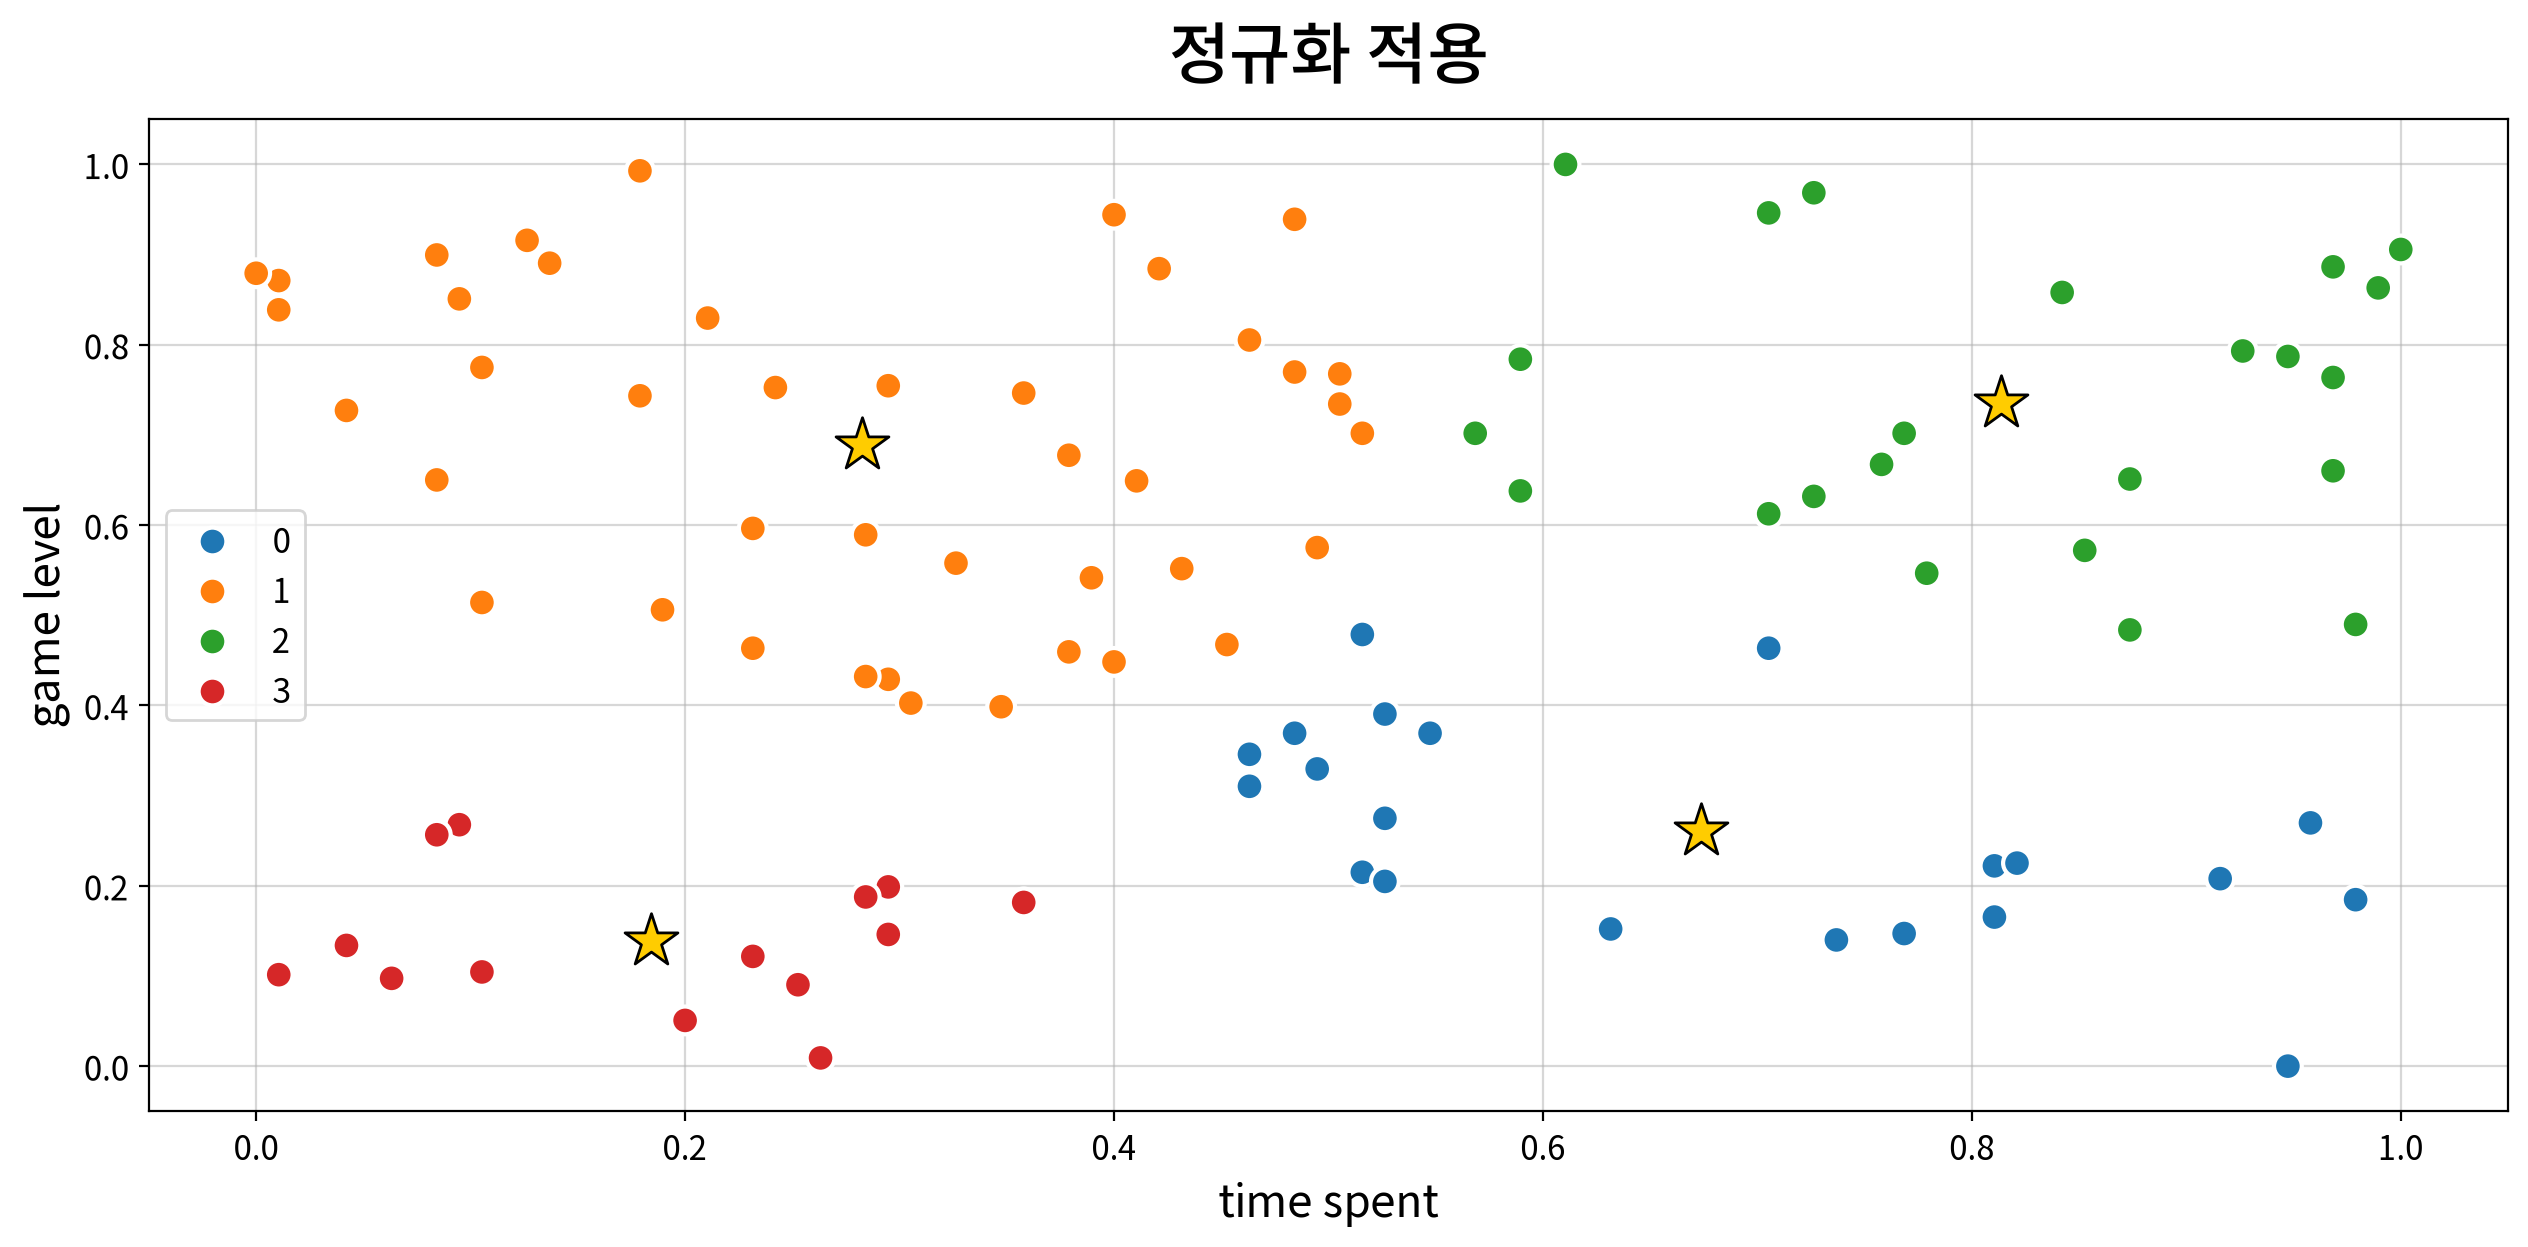

In [17]:
estimator, df, center_df = my_cluster.kmeans(origin, k=4,
                                              scaling="minmax", outline=False,
                                              center_marker="*", center_size=400,
                                              center_color="#ffcc00",
                                              center_edgecolor="#000000",
                                              center_linewidth=1, title="정규화 적용")

### 4. 시각화 없이 결과만 반환받기 

In [19]:
estimator, df, center_df = my_cluster.kmeans(origin, k=3, 
                                             plot=False, verbose=False)
center_df

,time spent,game level
0,-0.120,-1.037
1,-0.700,0.742
2,1.172,0.621


## # 연습문제 